# Phase 2 Step 4 — BL Yearly Rebalance Backtest (`04_BL_yearly_rebalance.ipynb`)

> **목적**: 5 시나리오 BL 백테스트 + 직접 비교로 ML 통합의 portfolio 성과 효과 정량화.

## 5 시나리오

| 시나리오 | 설명 | P 행렬 입력 |
|---|---|---|
| A. **BL_trailing** | 서윤범 baseline | vol_21d (trailing) |
| **B. BL_ml** ⭐ | **Phase 2 ensemble** | **ML 예측 변동성** |
| C. SPY | 시장 벤치마크 | (가중치 없음, ETF 직접) |
| D. EqualWeight | 1/N 등가 | (DeMiguel 강력 baseline) |
| E. McapWeight | 시총 가중 | (S&P 인덱스 방식) |

## 결정사항 8 (PLAN.md §2)

1. 거래비용: 0 default, 인자화 (`TRANSACTION_COST = 0.0`)
2-8. (Step 1-3 에서 이미 적용)

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + autoreload + 모듈 import |
| §2 | 데이터 로드 (universe / panel / market / ensemble) |
| §3 | 헬퍼 함수 (월별 ret, mcap 매핑) |
| §4 | 5 시나리오 백테스트 루프 |
| §5 | 메트릭 계산 + 비교 표 |
| §6 | 시각화 (누적수익, drawdown, rolling Sharpe) |
| §7 | 결과 저장 |


## §1. 환경 부트스트랩

In [1]:
# Jupyter 모듈 자동 리로드
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, BASE_DIR, DATA_DIR, OUTPUTS_DIR
from scripts.black_litterman import (
    compute_pi, build_P, compute_omega, black_litterman, optimize_portfolio,
    Q_FIXED, PCT_GROUP, DEFAULT_TAU,
)
from scripts.covariance import (
    compute_sigma_daily, daily_to_monthly, estimate_covariance, DAYS_PER_MONTH,
)
from scripts.backtest import (
    backtest_strategy, handle_delisting,
    compute_portfolio_metrics, compute_cumulative_curve, compute_drawdown_curve,
)
from scripts.benchmarks import (
    equal_weight_portfolio, mcap_weight_portfolio, spy_returns,
)

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '04_bl_yearly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nQ_FIXED = {Q_FIXED}')
print(f'PCT_GROUP = {PCT_GROUP}')
print(f'DEFAULT_TAU = {DEFAULT_TAU}')

  Phase 2 BL Integration — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility

Q_FIXED = 0.003
PCT_GROUP = 0.3
DEFAULT_TAU = 0.05


## §2. 데이터 로드 (4 종)

In [2]:
# 2-1. universe
universe = pd.read_csv(DATA_DIR / 'universe_top50_history.csv', parse_dates=['cutoff_date'])
print(f'universe: {universe.shape} (unique {universe["ticker"].nunique()} 종목)')

# 2-2. daily_panel (대용량 — 필요 컬럼만)
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'log_ret', 'vol_21d', 'mcap_value', 'log_mcap', 'spy_close', 'rf_daily']
)
print(f'panel: {panel.shape}')

# 2-3. ensemble predictions (Step 3 산출)
ens = pd.read_csv(DATA_DIR / 'ensemble_predictions_top50.csv', parse_dates=['date'])
print(f'ensemble: {ens.shape}')

# 2-4. market data
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
print(f'market: {market.shape}')

universe: (300, 6) (unique 74 종목)


panel: (241422, 8)
ensemble: (142338, 9)
market: (3271, 3)


## §3. 헬퍼 함수 (월별 ret, mcap 매핑, 일별 ret 매트릭스)

In [3]:
# 3-1. 일별 log_ret pivot (Σ 계산용)
daily_lr = panel.pivot_table(index='date', columns='ticker', values='log_ret')
print(f'daily_lr: {daily_lr.shape}')

# 3-2. 월별 단순 수익률 (월말 endpoint)
def compute_monthly_returns_for_universe(panel_df, universe_tickers, start_date, end_date):
    """종목별 월말 가격 → 월별 단순 수익률."""
    sub = panel_df[panel_df['ticker'].isin(universe_tickers) &
                   (panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]
    sub = sub.set_index('date')
    # 종가 reconstruction: log_ret cumsum → exp → 가격 (단조)
    # 그러나 panel 에는 close 컬럼 없음 → spy_close 만 있음
    # 대안: log_ret 의 월별 합 → exp 변환
    sub['month'] = sub.index.to_period('M')
    monthly_lr = sub.groupby(['ticker', 'month'])['log_ret'].sum().reset_index()
    monthly_lr['date'] = monthly_lr['month'].dt.to_timestamp(how='end').dt.normalize()
    monthly_lr['ret'] = np.exp(monthly_lr['log_ret']) - 1
    return monthly_lr.pivot_table(index='date', columns='ticker', values='ret')

# 3-3. mcap 매핑 (월별 시점)
def get_mcap_at_date(panel_df, date, tickers):
    """특정 시점 종목별 mcap_value (가까운 과거)."""
    sub = panel_df[(panel_df['date'] <= date) & (panel_df['ticker'].isin(tickers))]
    sub = sub.sort_values(['ticker', 'date']).groupby('ticker').last()
    return sub['mcap_value'].dropna()

# 3-4. 매월 BL 리밸런싱 시점 (월별 마지막 거래일)
# market.index 를 월별로 그룹화 후 각 월의 마지막 거래일 추출
market_lastday_per_month = market.groupby(market.index.to_period('M')).tail(1)
rebalance_dates = market_lastday_per_month.index
rebalance_dates = rebalance_dates[(rebalance_dates >= '2018-04-01') & (rebalance_dates <= '2025-12-31')]
print(f'\nrebalance_dates: {len(rebalance_dates)} 개월 ({rebalance_dates[0].date()} ~ {rebalance_dates[-1].date()})')

daily_lr: (3270, 74)

rebalance_dates: 93 개월 (2018-04-30 ~ 2025-12-31)


## §4. 5 시나리오 BL 백테스트 (매월 리밸런싱)

⚠️ 누수 방지:
- 매월 시점 t 의 가중치 결정 시 t 이전 정보만 사용
- IS 데이터 = (t-5년) ~ (t-1일)
- 다음 달 수익률은 t+1 시점에 반영


In [4]:
# 4-1. 백테스트 파라미터
TRANSACTION_COST = 0.0      # 결정 1: 0 default, 인자화
TAU = DEFAULT_TAU           # 0.05
IS_LEN_DAYS = 1260          # 5년 (Σ 계산 IS)

# 4-2. 매월 ensemble 예측치 (월말 endpoint 매핑)
ens['month'] = ens['date'].dt.to_period('M')
ens_monthly = ens.groupby(['ticker', 'month']).last().reset_index()
ens_monthly['rebalance_date'] = ens_monthly['month'].dt.to_timestamp(how='end').dt.normalize()

# 4-3. 매월 trailing vol_21d (서윤범 baseline 입력)
panel['month'] = panel['date'].dt.to_period('M')
panel_monthly = panel.groupby(['ticker', 'month']).last().reset_index()
panel_monthly['rebalance_date'] = panel_monthly['month'].dt.to_timestamp(how='end').dt.normalize()

print(f'ens_monthly: {ens_monthly.shape}')
print(f'panel_monthly: {panel_monthly.shape}')

ens_monthly: (6852, 11)
panel_monthly: (11586, 10)


In [5]:
# 4-4. 백테스트 메인 루프
weights_history = {
    'BL_trailing': {},
    'BL_ml': {},
    'EqualWeight': {},
    'McapWeight': {},
}
diagnostics = []

for i, t in enumerate(rebalance_dates):
    # 본 시점 universe (그 해의 50 종목)
    year = t.year
    universe_year = universe[universe['oos_year'] == year]['ticker'].tolist()
    if len(universe_year) == 0:
        continue

    # IS 데이터 (지난 5년)
    is_start = t - pd.Timedelta(days=int(IS_LEN_DAYS * 365.25 / 252))
    is_end = t - pd.Timedelta(days=1)

    # ─── 일별 log_ret 슬라이싱 (universe 50 종목, IS 기간) ───
    rets_is = daily_lr.loc[is_start:is_end, daily_lr.columns.intersection(universe_year)].dropna(how='all')
    valid_tickers = rets_is.dropna(axis=1, thresh=int(len(rets_is)*0.95)).columns.tolist()
    if len(valid_tickers) < 30:
        continue

    # ─── Σ 환산 (일별 + LedoitWolf + ×21) ───
    try:
        Sigma_monthly = estimate_covariance(rets_is[valid_tickers], is_start, is_end)
    except Exception as e:
        print(f'  {t.date()}: Σ 계산 실패 ({e}) → skip')
        continue

    # ─── mcap 매핑 ───
    mcaps_t = get_mcap_at_date(panel, t, valid_tickers)
    common_t = list(set(valid_tickers) & set(mcaps_t.index))
    if len(common_t) < 30:
        continue
    Sigma_t = Sigma_monthly.loc[common_t, common_t]
    mcaps_filt = mcaps_t.loc[common_t]

    # ─── 시장 데이터 (π 계산) ───
    spy_excess_t = market.loc[is_start:is_end, 'SPY']
    spy_lr = np.log(spy_excess_t / spy_excess_t.shift(1)).dropna()
    spy_excess_monthly = float(spy_lr.mean() * DAYS_PER_MONTH)  # 월별 환산
    sigma2_mkt = float(spy_lr.var() * DAYS_PER_MONTH)

    # 시장 가중치 = mcap 비례
    w_mkt = mcaps_filt / mcaps_filt.sum()

    # π, λ 계산
    pi, lam = compute_pi(Sigma_t, w_mkt, spy_excess_monthly, sigma2_mkt)

    # ─── 시나리오 A: BL_trailing (서윤범 baseline) ───
    panel_at_t = panel_monthly[panel_monthly['rebalance_date'] == t]
    panel_at_t = panel_at_t[panel_at_t['ticker'].isin(common_t)].set_index('ticker')
    if len(panel_at_t) < 30:
        continue
    vol_trailing = panel_at_t['vol_21d'].dropna()
    common_a = list(set(common_t) & set(vol_trailing.index))
    if len(common_a) >= 30:
        P_trail = build_P(vol_trailing.loc[common_a], mcaps_filt.loc[common_a], pct=PCT_GROUP)
        Sigma_a = Sigma_t.loc[common_a, common_a]
        pi_a = pi.loc[common_a]
        omega_a = compute_omega(P_trail, Sigma_a, TAU)
        mu_BL_a = black_litterman(pi_a, Sigma_a, P_trail, Q_FIXED, omega_a, TAU)
        try:
            w_a = optimize_portfolio(mu_BL_a, Sigma_a, lam)
            weights_history['BL_trailing'][t] = w_a
        except Exception:
            pass

    # ─── 시나리오 B: BL_ml (Phase 2 ensemble) ───
    ens_at_t = ens_monthly[ens_monthly['rebalance_date'] == t]
    ens_at_t = ens_at_t[ens_at_t['ticker'].isin(common_t)].set_index('ticker')
    if len(ens_at_t) >= 30:
        vol_ml = np.exp(ens_at_t['y_pred_ensemble'].dropna())  # log-RV → RV
        common_b = list(set(common_t) & set(vol_ml.index))
        if len(common_b) >= 30:
            P_ml = build_P(vol_ml.loc[common_b], mcaps_filt.loc[common_b], pct=PCT_GROUP)
            Sigma_b = Sigma_t.loc[common_b, common_b]
            pi_b = pi.loc[common_b]
            omega_b = compute_omega(P_ml, Sigma_b, TAU)
            mu_BL_b = black_litterman(pi_b, Sigma_b, P_ml, Q_FIXED, omega_b, TAU)
            try:
                w_b = optimize_portfolio(mu_BL_b, Sigma_b, lam)
                weights_history['BL_ml'][t] = w_b
            except Exception:
                pass

    # ─── 시나리오 D: EqualWeight ───
    weights_history['EqualWeight'][t] = equal_weight_portfolio(common_t)

    # ─── 시나리오 E: McapWeight ───
    weights_history['McapWeight'][t] = mcap_weight_portfolio(mcaps_filt, common_t)

    diagnostics.append({
        'date': t, 'n_universe': len(universe_year), 'n_valid': len(common_t),
        'lam': lam, 'spy_excess_m': spy_excess_monthly, 'sigma2_mkt_m': sigma2_mkt,
    })

    if (i+1) % 12 == 0:
        print(f'  진행: {i+1}/{len(rebalance_dates)} ({t.date()}) — universe {len(common_t)} 종목, λ={lam:.2f}')

diag_df = pd.DataFrame(diagnostics).set_index('date')
print(f'\n백테스트 완료: {len(diag_df)} 개월')
print(f'각 시나리오 가중치 산출 시점:')
for k, v in weights_history.items():
    print(f'  {k}: {len(v)} 개월')

  진행: 24/93 (2020-03-31) — universe 50 종목, λ=2.12


  진행: 36/93 (2021-03-31) — universe 50 종목, λ=4.21


  진행: 48/93 (2022-03-31) — universe 50 종목, λ=3.97


  진행: 60/93 (2023-03-31) — universe 50 종목, λ=2.32


  진행: 84/93 (2025-03-31) — universe 50 종목, λ=5.50



백테스트 완료: 51 개월
각 시나리오 가중치 산출 시점:
  BL_trailing: 51 개월
  BL_ml: 51 개월
  EqualWeight: 51 개월
  McapWeight: 51 개월


## §5. 메트릭 계산 + 시나리오 비교 표

In [6]:
# 5-1. 월별 수익률 매트릭스 (전 universe)
all_universe_tickers = sorted(universe['ticker'].unique().tolist())
monthly_rets = compute_monthly_returns_for_universe(
    panel, all_universe_tickers,
    rebalance_dates[0] - pd.DateOffset(years=1),
    rebalance_dates[-1] + pd.DateOffset(months=1),
)
print(f'monthly_rets: {monthly_rets.shape}')

# 5-2. SPY 월별 수익률
spy_monthly_ret = spy_returns(market, rebalance_dates, return_type='monthly').dropna()
print(f'spy_monthly_ret: {len(spy_monthly_ret)} 개월')

# 5-3. 무위험 수익률 (월별)
rf_daily_avg = panel.groupby('date')['rf_daily'].first()
rf_monthly = (1 + rf_daily_avg).groupby(pd.Grouper(freq='ME')).apply(lambda x: x.prod()) - 1
rf_monthly.index = rf_monthly.index.normalize()

monthly_rets: (104, 74)
spy_monthly_ret: 92 개월


In [7]:
# 5-4. 시나리오별 portfolio return 시뮬레이션
portfolio_returns_dict = {}

# A, B, D, E: weights_history 기반
for scenario in ['BL_trailing', 'BL_ml', 'EqualWeight', 'McapWeight']:
    w_dict = weights_history[scenario]
    if not w_dict:
        continue
    # weights_history → DataFrame (rebalance × ticker)
    w_df = pd.DataFrame(w_dict).T.fillna(0)
    w_df.index = pd.DatetimeIndex(w_df.index)

    portfolio_returns_dict[scenario] = backtest_strategy(
        weights_history=w_df,
        returns=monthly_rets,
        transaction_cost=TRANSACTION_COST,
    )

# C: SPY 직접 수익률
portfolio_returns_dict['SPY'] = spy_monthly_ret.reindex(rebalance_dates).dropna()

print('=== 시나리오별 월별 수익률 시계열 ===')
for k, v in portfolio_returns_dict.items():
    print(f'  {k}: {len(v)} 개월, mean={v.mean()*100:+.3f}%/월, std={v.std()*100:.3f}%')

=== 시나리오별 월별 수익률 시계열 ===
  BL_trailing: 51 개월, mean=+2.006%/월, std=4.361%
  BL_ml: 51 개월, mean=+1.560%/월, std=3.969%
  EqualWeight: 51 개월, mean=+1.299%/월, std=4.776%
  McapWeight: 51 개월, mean=+2.302%/월, std=5.099%
  SPY: 92 개월, mean=+1.281%/월, std=4.785%


In [8]:
# 5-5. 메트릭 계산 (각 시나리오)
metrics_summary = {}
for scenario, port_rets in portfolio_returns_dict.items():
    benchmark = portfolio_returns_dict.get('SPY')
    metrics = compute_portfolio_metrics(
        port_rets, benchmark_returns=benchmark, rf_returns=rf_monthly,
        periods_per_year=12,
    )
    metrics_summary[scenario] = metrics

metrics_df = pd.DataFrame(metrics_summary).T
print('=' * 80)
print('🎯 5 시나리오 메트릭 비교')
print('=' * 80)
print(metrics_df[['cum_return', 'annualized_return', 'annualized_vol',
                  'sharpe', 'max_drawdown', 'calmar']].round(4).to_string())

# alpha / beta (벤치마크 있는 경우만)
if 'alpha' in metrics_df.columns:
    print('\n=== Alpha / Beta (vs SPY) ===')
    print(metrics_df[['alpha', 'beta']].round(4).to_string())

🎯 5 시나리오 메트릭 비교
             cum_return  annualized_return  annualized_vol   sharpe  max_drawdown   calmar
BL_trailing    1.631700           0.240700        0.151100 1.412700     -0.155800 1.544800
BL_ml          1.120400           0.187200        0.137500 1.163400     -0.146200 1.280400
EqualWeight    0.825700           0.155800        0.165500 0.776900     -0.239500 0.650700
McapWeight     1.997800           0.276300        0.176600 1.409600     -0.231600 1.192800
SPY            1.909400           0.153800        0.165800 0.817200     -0.239300 0.642700

=== Alpha / Beta (vs SPY) ===
                alpha     beta
BL_trailing  0.113700 0.764000
BL_ml        0.070300 0.686800
EqualWeight  0.006800 0.932900
McapWeight   0.123100 0.964500
SPY         -0.000000 1.000000


## §6. 시각화 (누적수익 / drawdown / rolling Sharpe)

C:\Users\gorhk\AppData\Local\Temp\ipykernel_14392\3033958359.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(scenarios_sorted, rotation=15, ha='right')


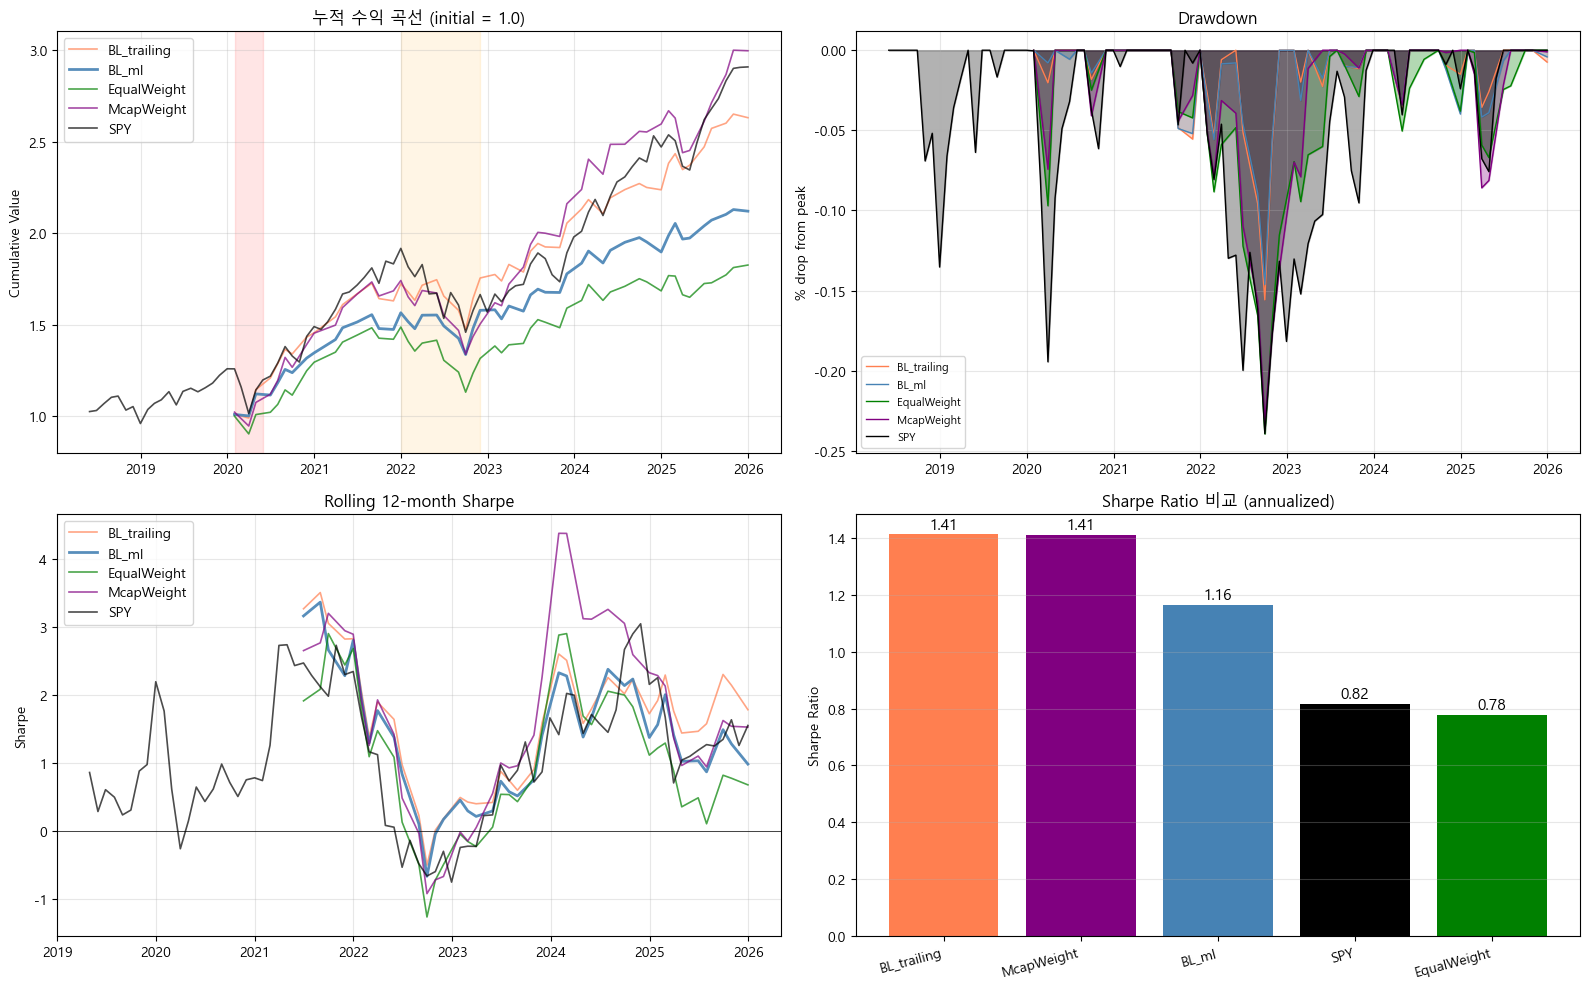

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = {
    'BL_trailing': 'coral',
    'BL_ml': 'steelblue',
    'SPY': 'black',
    'EqualWeight': 'green',
    'McapWeight': 'purple',
}

# 6-1. 누적 수익 곡선
ax = axes[0, 0]
for scenario, port_rets in portfolio_returns_dict.items():
    cum = compute_cumulative_curve(port_rets)
    ax.plot(cum.index, cum.values, label=scenario, color=colors.get(scenario, 'gray'),
            lw=2 if scenario == 'BL_ml' else 1.2,
            alpha=0.9 if scenario == 'BL_ml' else 0.7)
ax.set_title('누적 수익 곡선 (initial = 1.0)')
ax.set_ylabel('Cumulative Value')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.axvspan(pd.Timestamp('2020-02'), pd.Timestamp('2020-06'), alpha=0.1, color='red', label='COVID')
ax.axvspan(pd.Timestamp('2022-01'), pd.Timestamp('2022-12'), alpha=0.1, color='orange', label='긴축')

# 6-2. Drawdown
ax = axes[0, 1]
for scenario, port_rets in portfolio_returns_dict.items():
    dd = compute_drawdown_curve(port_rets)
    ax.fill_between(dd.index, dd.values, 0, alpha=0.3, color=colors.get(scenario, 'gray'))
    ax.plot(dd.index, dd.values, label=scenario, color=colors.get(scenario, 'gray'), lw=1)
ax.set_title('Drawdown')
ax.set_ylabel('% drop from peak')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)

# 6-3. Rolling 12개월 Sharpe
ax = axes[1, 0]
for scenario, port_rets in portfolio_returns_dict.items():
    rolling_sharpe = (port_rets.rolling(12).mean() / port_rets.rolling(12).std() * np.sqrt(12))
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=scenario,
            color=colors.get(scenario, 'gray'),
            lw=2 if scenario == 'BL_ml' else 1.2,
            alpha=0.9 if scenario == 'BL_ml' else 0.7)
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_title('Rolling 12-month Sharpe')
ax.set_ylabel('Sharpe')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# 6-4. Sharpe / Alpha 막대그래프
ax = axes[1, 1]
scenarios_sorted = metrics_df.sort_values('sharpe', ascending=False).index.tolist()
sharpe_vals = [metrics_summary[s]['sharpe'] for s in scenarios_sorted]
ax.bar(scenarios_sorted, sharpe_vals, color=[colors.get(s, 'gray') for s in scenarios_sorted])
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio 비교 (annualized)')
for i, v in enumerate(sharpe_vals):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_xticklabels(scenarios_sorted, rotation=15, ha='right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_yearly_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## §7. 결과 저장

In [10]:
# 7-1. 시나리오별 weights, returns 저장
import json

# weights (BL_ml 만 우선 — Step 5 의 핵심 산출물)
for scenario, w_dict in weights_history.items():
    if not w_dict: continue
    w_df = pd.DataFrame(w_dict).T.fillna(0)
    w_df.index = pd.DatetimeIndex(w_df.index)
    w_df.to_csv(DATA_DIR / f'bl_weights_{scenario}.csv')

# returns
returns_df = pd.DataFrame(portfolio_returns_dict)
returns_df.to_csv(DATA_DIR / 'portfolio_returns_5scenarios.csv')

# metrics
metrics_df.to_csv(DATA_DIR / 'bl_metrics_5scenarios.csv')

# diag
diag_df.to_csv(DATA_DIR / 'bl_diagnostics.csv')

print('=== 산출물 저장 ===')
print(f'  data/bl_weights_*.csv          (4 시나리오)')
print(f'  data/portfolio_returns_5scenarios.csv')
print(f'  data/bl_metrics_5scenarios.csv')
print(f'  data/bl_diagnostics.csv')
print(f'  outputs/04_bl_yearly/bl_yearly_comparison.png')

# 핵심 결론 요약
print('\n' + '=' * 80)
print('🏁 Step 4 핵심 결론')
print('=' * 80)
sorted_metrics = metrics_df.sort_values('sharpe', ascending=False)
print(f'\n1. Sharpe 순위:')
for i, (scenario, row) in enumerate(sorted_metrics.iterrows(), 1):
    print(f'   {i}. {scenario:15s}  Sharpe={row["sharpe"]:.3f}  CumRet={row["cum_return"]*100:+.1f}%  MDD={row["max_drawdown"]*100:.1f}%')

if 'BL_ml' in metrics_summary and 'BL_trailing' in metrics_summary:
    diff_sharpe = metrics_summary['BL_ml']['sharpe'] - metrics_summary['BL_trailing']['sharpe']
    print(f'\n2. ⭐ BL_ml vs BL_trailing 의 Sharpe 차이: {diff_sharpe:+.3f}')
    print(f'   ML 통합 가치 = {"YES (양수)" if diff_sharpe > 0 else "NO (음수)"}')

=== 산출물 저장 ===
  data/bl_weights_*.csv          (4 시나리오)
  data/portfolio_returns_5scenarios.csv
  data/bl_metrics_5scenarios.csv
  data/bl_diagnostics.csv
  outputs/04_bl_yearly/bl_yearly_comparison.png

🏁 Step 4 핵심 결론

1. Sharpe 순위:
   1. BL_trailing      Sharpe=1.413  CumRet=+163.2%  MDD=-15.6%
   2. McapWeight       Sharpe=1.410  CumRet=+199.8%  MDD=-23.2%
   3. BL_ml            Sharpe=1.163  CumRet=+112.0%  MDD=-14.6%
   4. SPY              Sharpe=0.817  CumRet=+190.9%  MDD=-23.9%
   5. EqualWeight      Sharpe=0.777  CumRet=+82.6%  MDD=-23.9%

2. ⭐ BL_ml vs BL_trailing 의 Sharpe 차이: -0.249
   ML 통합 가치 = NO (음수)


## 다음 단계

→ **Step 5**: `05_comparison.ipynb` — 시기별 분해 + τ 민감도 + 거래비용 sensitivity + 종합 보고서.